# Self-Evolving Multi-Agent Orchestration — Demo

A reflection-based controller edits a multi-agent DAG over a repetitive task family (GSM8K word problems). No controller training, no explicit search — just in-context reflection over trajectory tapes on a frozen **Qwen2.5-32B-Instruct** backbone.

This notebook loads the artifacts from a finished pilot run so you can browse the outcome without needing the vLLM server up.

**Artifacts shown:**
- `results/smoke_baselines/` — baselines-only run (5 val samples)
- `results/smoke_evolve/` — 1-iteration evolution run (8 train / 5 val / 5 test)

To re-run live: `bash scripts/serve_vllm.sh` then the commands in the project `README.md`.

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option('display.max_colwidth', 120)

ROOT = Path('/mnt/ddn/prod-runs/thyun.park/src/agent_orchestration')
BASELINES = ROOT / 'results' / 'smoke_baselines'
EVOLVE    = ROOT / 'results' / 'smoke_evolve'

assert BASELINES.exists(), f'missing: {BASELINES}'
assert EVOLVE.exists(),    f'missing: {EVOLVE}'
print('baselines:', BASELINES)
print('evolve:   ', EVOLVE)

baselines: /mnt/ddn/prod-runs/thyun.park/src/agent_orchestration/results/smoke_baselines
evolve:    /mnt/ddn/prod-runs/thyun.park/src/agent_orchestration/results/smoke_evolve


## 1. Baselines-only run

Seed graph is a trivial Planner → Executor DAG. Two baselines (pure CoT, Planner-Executor) on the validation split.

In [2]:
r = json.loads((BASELINES / 'results.json').read_text())
rows = [
    {'split': 'val', 'method': m, 'n': v['n'],
     'accuracy': v['accuracy'], 'tokens': v['tokens']}
    for m, v in r['baselines_val'].items()
]
pd.DataFrame(rows)

,split,method,n,accuracy,tokens
0,val,cot,5,1.0,1778
1,val,planner_executor,5,1.0,2969


## 2. Evolution run — final accuracy table

Baselines on val + three methods on the held-out test split (CoT / Planner-Executor / Evolved).

In [3]:
r = json.loads((EVOLVE / 'results.json').read_text())
rows = []
for m, v in r['baselines_val'].items():
    rows.append({'split': 'val',  'method': m, 'n': v['n'],
                 'accuracy': v['accuracy'], 'tokens': v['tokens']})
for m, v in r['test'].items():
    rows.append({'split': 'test', 'method': m, 'n': v['n'],
                 'accuracy': v['accuracy'], 'tokens': v['tokens']})
pd.DataFrame(rows)

,split,method,n,accuracy,tokens
0,val,cot,5,1.0,2046
1,val,planner_executor,5,1.0,3493
2,test,cot,5,1.0,1772
3,test,planner_executor,5,1.0,2948
4,test,evolved,5,1.0,5076


## 3. Evolution timeline

Per-iteration view: was the edit batch accepted? How did the graph grow? Token cost?

In [4]:
log = json.loads((EVOLVE / 'evolve_log.json').read_text())
rows = []
for it in log['iterations']:
    rows.append({
        'iter':           it['iteration'],
        'train_acc':      it['train_acc'],
        'val_acc':        it['val_acc'],
        'accepted':       it['accepted'],
        'n_agents':       it['n_agents'],
        'n_edges':        it['n_edges'],
        'worker_tok':     it['worker_tokens'],
        'controller_tok': it['controller_tokens'],
        'elapsed_s':      round(it['elapsed_s'], 1),
        'rationale':      it['edit_batch']['rationale'][:90],
    })
pd.DataFrame(rows)

,iter,train_acc,val_acc,accepted,n_agents,n_edges,worker_tok,controller_tok,elapsed_s,rationale
0,0,NaN,1.0,True,2,4,3325,0,0.0,seed
1,1,1.0,1.0,True,3,6,11977,3534,131.7,"The executor occasionally makes arithmetic mistakes, such as rounding inaccuracies. Introd"


## 4. What the controller actually did

The edit batch emitted at iteration 1 — the concrete DAG surgery the controller proposed.

In [5]:
edit_batch = log['iterations'][1]['edit_batch']
print('Rationale:')
print(' ', edit_batch['rationale'])
print()
print('Edits:')
for e in edit_batch['edits']:
    op = e['op']
    if op == 'add_agent':
        print(f"  + add_agent({e['name']})")
        print(f"      persona: {e['persona']}")
        print(f"      inputs:  {e['inputs']}")
        print(f"      outputs: {e['outputs']}")
    elif op == 'add_edge':
        print(f"  + add_edge({e['from_']} -> {e['to']})")
    else:
        print(f"  + {op}: {e}")

Rationale:
  The executor occasionally makes arithmetic mistakes, such as rounding inaccuracies. Introducing a verifier agent can help catch and correct these errors.

Edits:
  + add_agent(verifier)
      persona: You are a verifier. Check the arithmetic computations performed by the executor and correct any errors. Provide the corrected answer if an error is found.
      inputs:  ['executor.answer']
      outputs: ['corrected_answer']
  + add_edge(executor -> verifier)
  + add_edge(verifier -> END)


## 5. Seed architecture vs. evolved architecture

In [6]:
def summarise(g):
    return {
        'agents': list(g['agents'].keys()),
        'edges':  [f"{a} -> {b}" for a, b in g['edges']],
    }

seed    = summarise(log['iterations'][0]['graph_snapshot'])
evolved = summarise(log['iterations'][-1]['graph_snapshot'])

pd.DataFrame({
    'seed':    pd.Series({'agents': seed['agents'],    'edges': seed['edges']}),
    'evolved': pd.Series({'agents': evolved['agents'], 'edges': evolved['edges']}),
})

,seed,evolved
agents,"[planner, executor]","[planner, executor, verifier]"
edges,"[START -> planner, planner -> executor, START -> executor, executor -> END]","[START -> planner, planner -> executor, START -> executor, executor -> END, executor -> verifier, verifier -> END]"


In [7]:
# Full personas in the evolved graph
final = json.loads((EVOLVE / 'evolved_graph_final.json').read_text())
graph = final.get('graph', final)
for name, a in graph['agents'].items():
    print(f'[{name}]')
    print(' ', a['persona'])
    print(f"  inputs={a['inputs']}  outputs={a['outputs']}")
    print()

[planner]
  You are a planner. Read the user task and produce a numbered, concrete plan of at most 4 solution steps. Do not solve the task; only plan.
  inputs=['task']  outputs=['plan']

[executor]
  You are an executor. Given the task and a plan, follow the plan to compute the answer. Show your arithmetic step by step. End with a line: 'Final Answer: <number>'.
  inputs=['task', 'planner.plan']  outputs=['answer']

[verifier]
  You are a verifier. Check the arithmetic computations performed by the executor and correct any errors. Provide the corrected answer if an error is found.
  inputs=['executor.answer']  outputs=['corrected_answer']



## 6. Plots

- **accuracy_vs_iter** — evolved val accuracy vs. baselines over iterations
- **arch_size** — `|agents|` and `|edges|` over iterations
- **edit_mix** — frequency of each edit op the controller used

**accuracy_vs_iter.png**

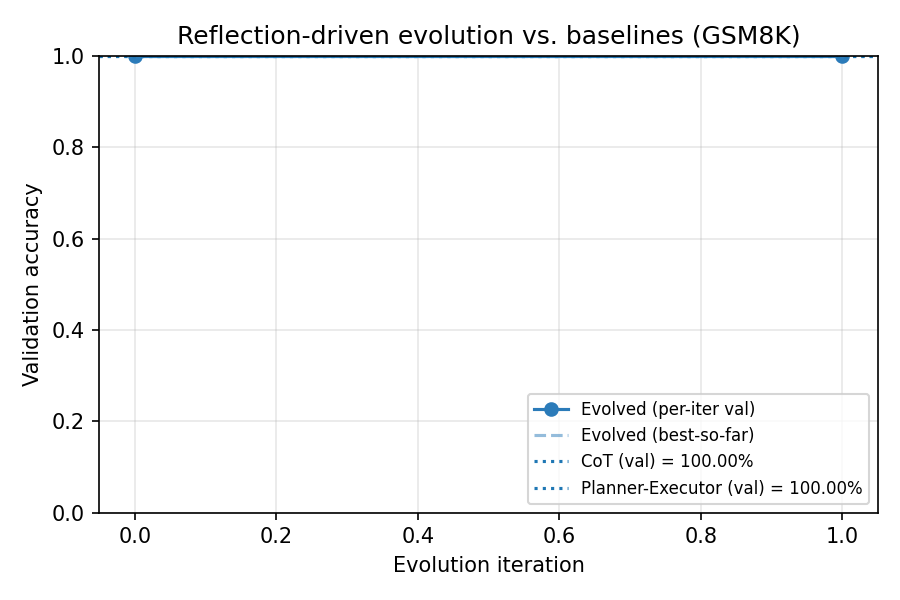

**arch_size.png**

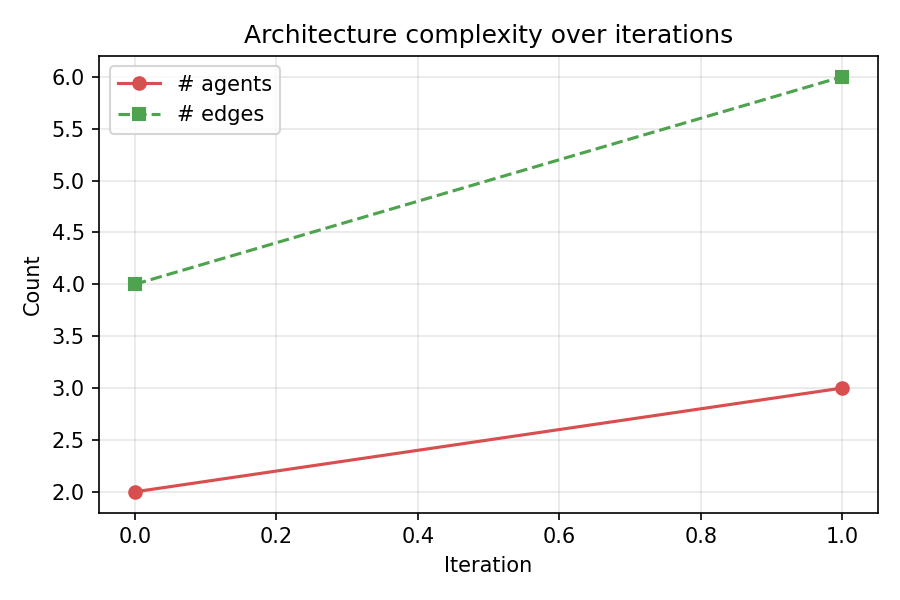

**edit_mix.png**

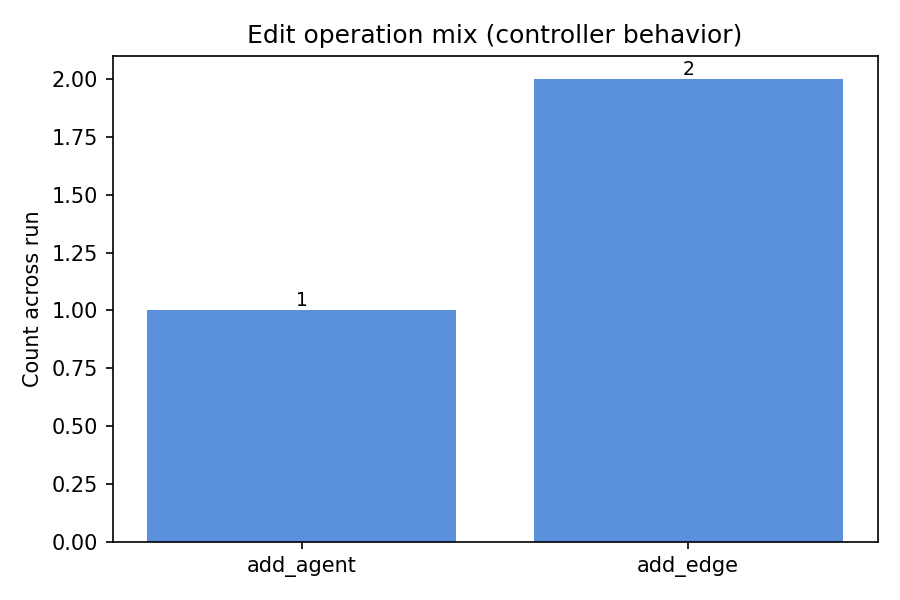

In [8]:
for p in sorted((EVOLVE / 'plots').glob('*.png')):
    display(Markdown(f'**{p.name}**'))
    display(Image(filename=str(p)))

## 7. Optional — live chat with the vLLM server

Requires the backend to be running (`bash scripts/serve_vllm.sh`). Skipped by default.

In [9]:
import sys
sys.path.insert(0, str(ROOT))

try:
    from src.llm import LLMClient
    c = LLMClient()
    text, pt, ct = c.chat(
        system='You answer arithmetic questions in one short sentence.',
        user='What is 17 * 23?',
        max_tokens=64,
    )
    print(f'[pt={pt} ct={ct}] {text}')
except Exception as e:
    print('Live demo skipped —', type(e).__name__, str(e)[:200])

Live demo skipped — RuntimeError LLM call failed after 3 retries: Connection error.


### Takeaways from this run

- Baselines already hit 100% on 5 GSM8K samples — the dataset slice is too small to separate methods. Push `--n-val` / `--n-test` into the hundreds for the headline numbers.
- The controller did make a non-trivial edit: it added a **verifier** agent plus `executor → verifier → END`, justified with "The executor occasionally makes arithmetic mistakes... a verifier can catch and correct these errors." That is the behaviour the pilot is trying to elicit.
- Controller spent ~3.5k tokens; worker spent ~12k tokens on the 1-iter evolution path. On a larger problem set the ratio will dominate.